In [1]:
import sys
import os
sys.path.append(os.path.abspath("../"))

In [2]:
from utils.loaders import load_sweep
from utils.styles import apply
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

apply(context="paper", col="single")

save_path = "/Users/niaggar/Results"
folder = "study_mixture_layer_TWO_LAYERS__PLIN"

In [ ]:
from typing import List, cast
from utils.analysis import CBSProfiles

sweep_data = load_sweep(folder, base_path=Path(save_path))

N_TIME_BINS = 500
time_index_studies = [0, 50, 100, 200, 300, 400, 499]

data = {} # {thickness_multi: profile}
for name, loader in sweep_data.items():
    thickness_multi = loader.params.extra["thickness_multi"]
    data[thickness_multi] = cast(List[CBSProfiles], [])
    
    for it in time_index_studies:
        prof = cbs_profiles(
            loader.processed_cbs("farfield_cbs"),
            basis=linear, 
            time_index=it,
            reduce=keep,
        )
        prof.enhancement
        data[thickness_multi].append(prof)


ordered = sorted(data)
ncol = len(ordered)

print(f"Found {ncol} thicknesses: {ordered}")

Found 8 thicknesses: [0.1, 0.2, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0]


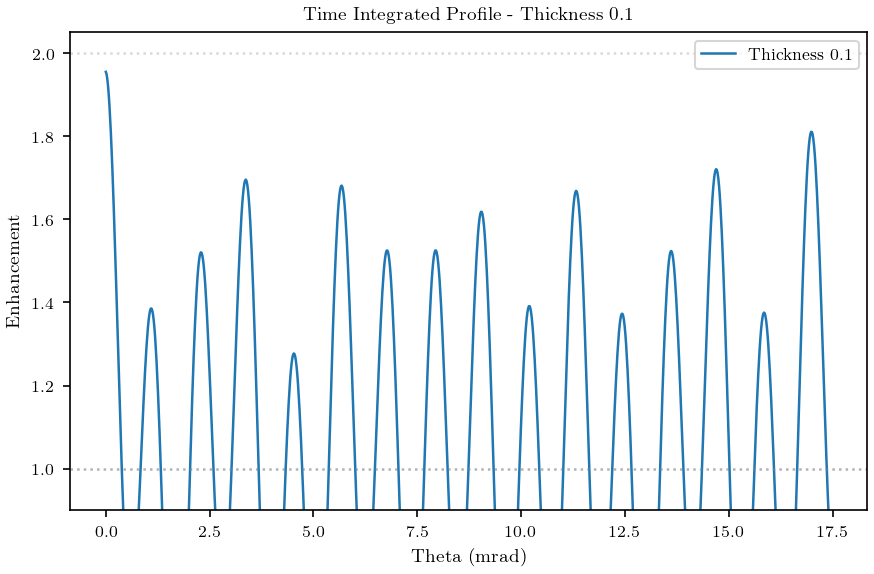

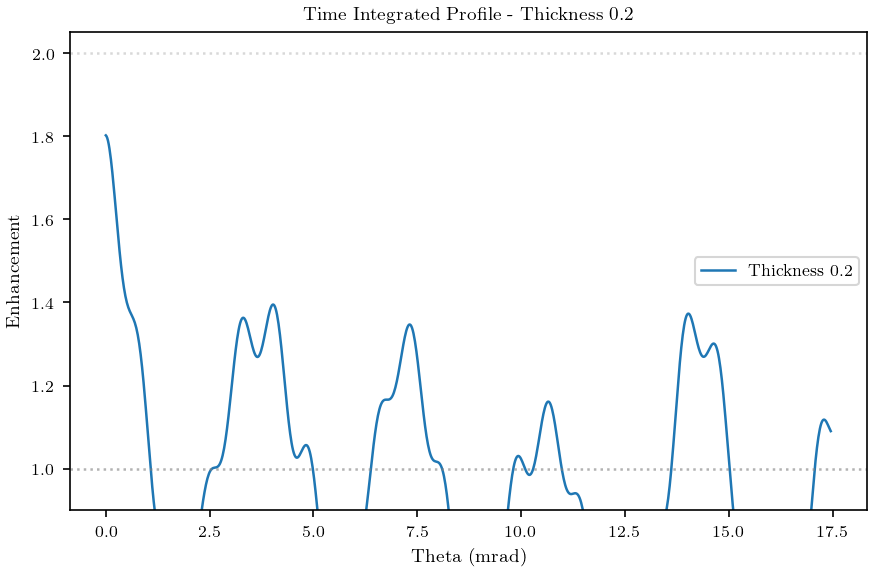

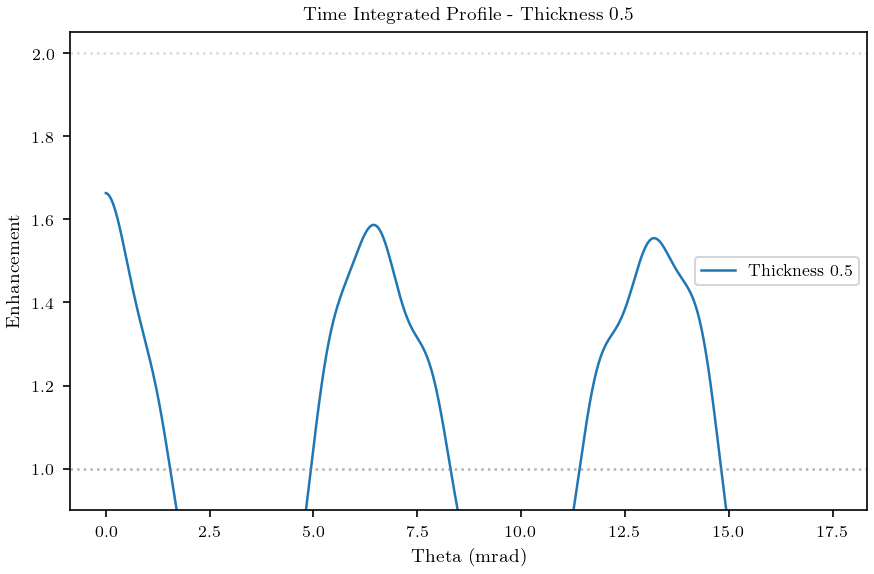

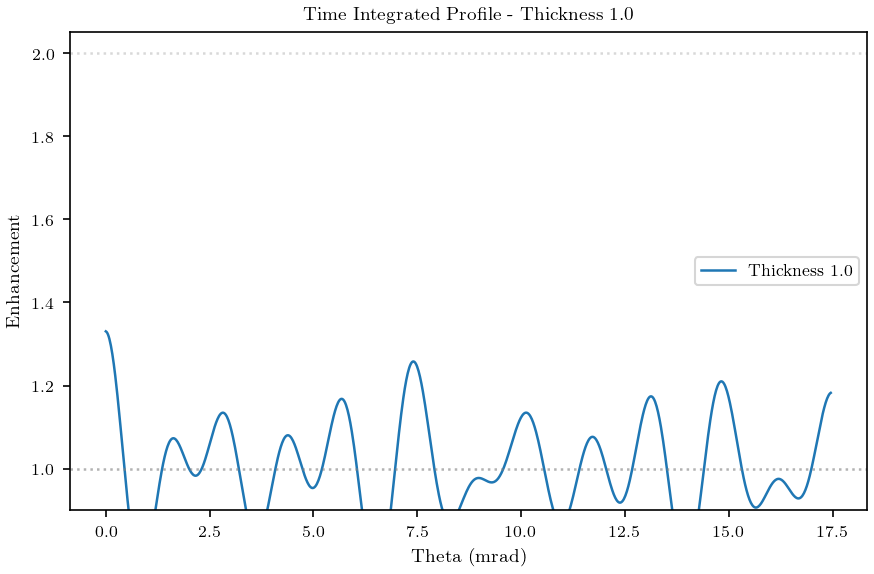

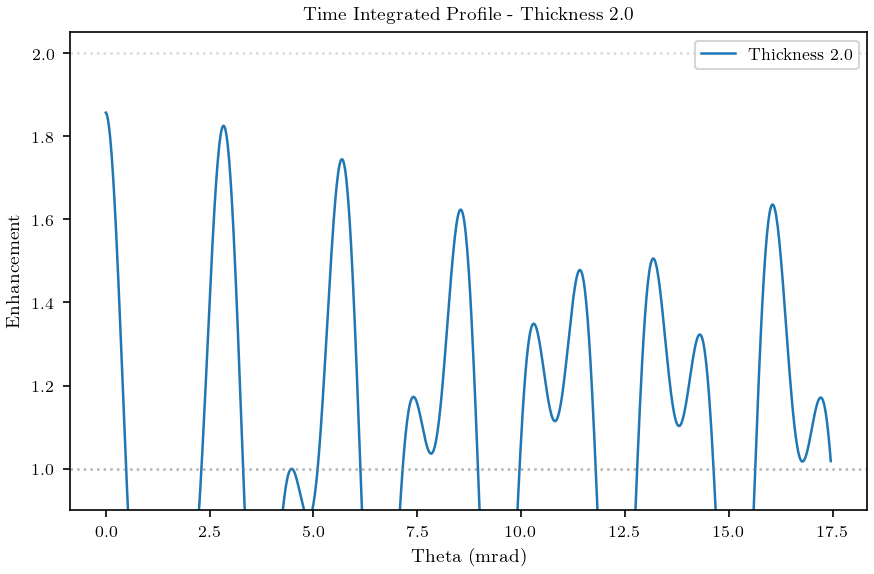

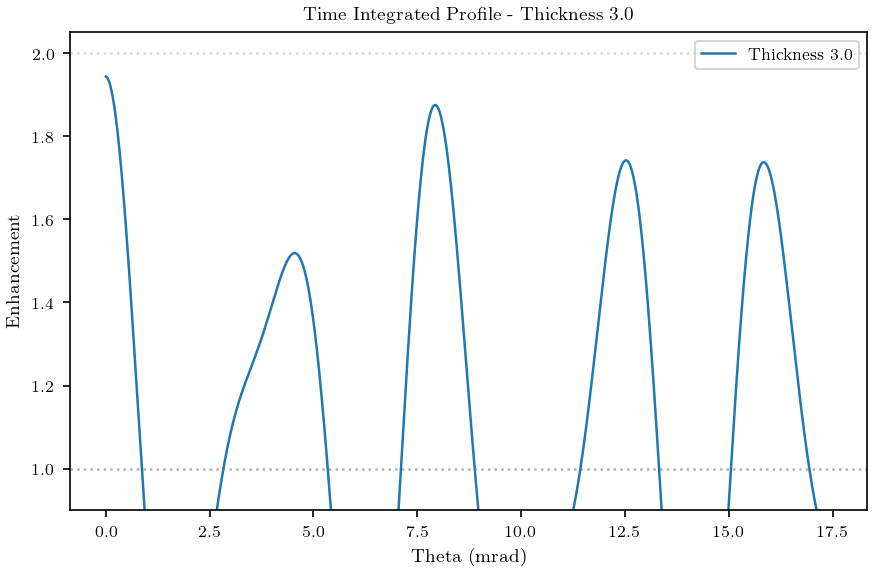

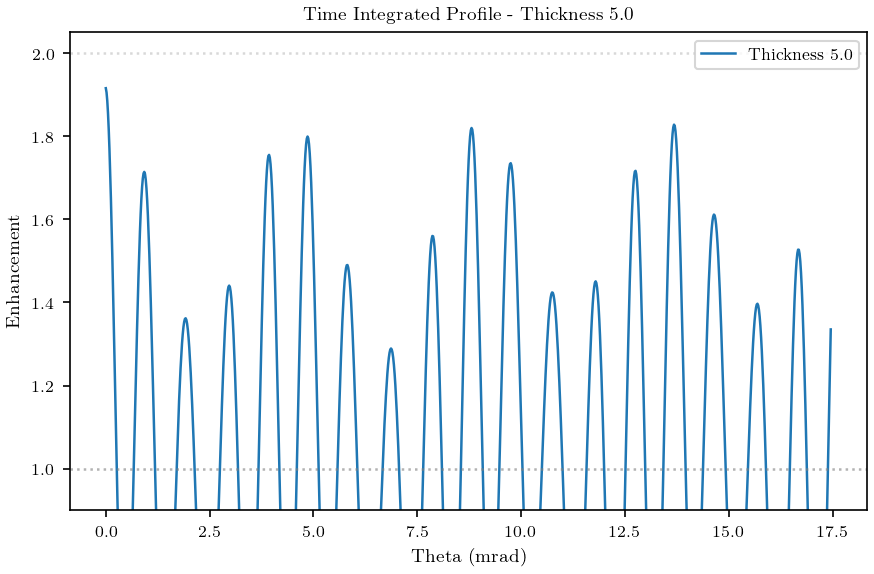

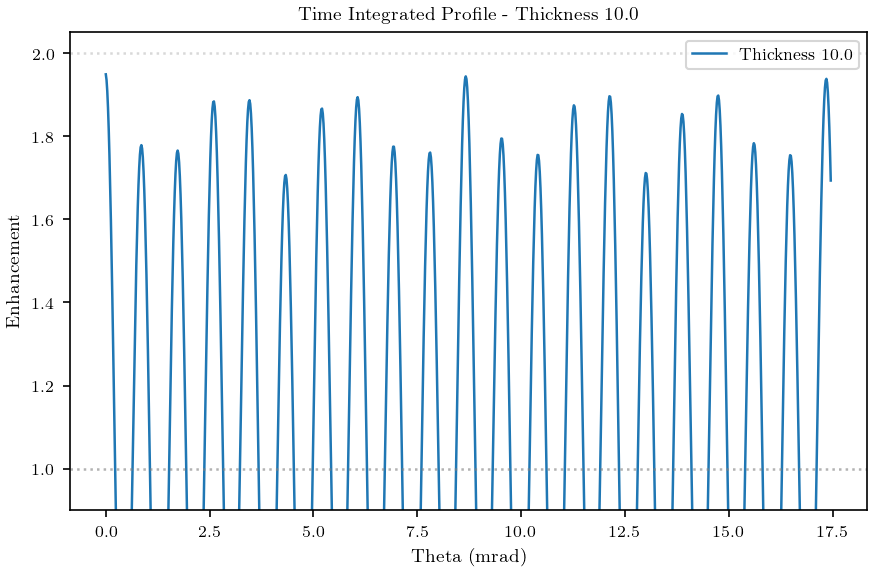

In [ ]:
# Plot the 0 time index for each thickness, this corresponds to the time integrated profile

for thickness_multi in ordered:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    profiles = data[thickness_multi]
    zero_time_profile = profiles[0]

    th = zero_time_profile.theta * 1e3
    x_0 = zero_time_profile.enhancement["co"][:, 0]
    ax.plot(th, x_0, color="C0", ls="-", label=f"Thickness {thickness_multi}")

    ax.set_xlabel("Theta (mrad)")
    ax.set_ylabel("Enhancement")
    ax.legend()
    ax.set_title(f"Time Integrated Profile - Thickness {thickness_multi}")

    ax.set_ylim(0.9, 2.05)
        ax.axhline(1.0, color="gray", ls=":", alpha=0.6)
    ax.axhline(2.0, color="gray", ls=":", alpha=0.3)

    plt.tight_layout()
    plt.show()
